# 01 - Exploratory Data Analysis (EDA)
**Project**: Interpretable Student Academic Risk Prediction  
**Course**: CSE2267 – Machine Learning Techniques  
**Institution**: Presidency University, Bengaluru  
**Assessment**: CA-III (Research Paper)

---

## 📌 Objectives of this Notebook
1. Load and inspect the **UCI Student Performance (Mathematics)** dataset.
2. Formulate the binary ground truth target: **`At_Risk`** ($G3 < 10$ out of 20).
3. Investigate missing data, column types, and statistical properties.
4. Explore univariate distributions of academic, demographic, and behavioral predictors.
5. Conduct bivariate analysis comparing features against academic risk status.
6. Identify key correlations and synthesize domain insights for modeling and SHAP explainability.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)

print("Environment configured and libraries loaded successfully!")

Environment configured and libraries loaded successfully!


## 1. Data Ingestion & Structural Inspection
The dataset is delimited with semicolons (`;`) and comprises 395 students with 33 attributes.

In [2]:
data_path = os.path.join("..", "data", "student-mat.csv")
df = pd.read_csv(data_path, sep=';')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 395 rows, 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 2. Data Quality & Missing Value Audit

In [3]:
print("Column Data Types and Non-Null Counts:")
df.info()

missing_total = df.isnull().sum().sum()
duplicates = df.duplicated().sum()
print(f"\nTotal Missing Values: {missing_total}")
print(f"Duplicate Rows: {duplicates}")

Column Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  high

## 3. Ground Truth Target Formulation: `At_Risk`
According to the Portuguese grading system (0–20 points):
- Scores $< 10$ represent failure (At-Risk = `1`).
- Scores $\ge 10$ represent passing (Not At-Risk = `0`).

In [4]:
df['At_Risk'] = (df['G3'] < 10).astype(int)

counts = df['At_Risk'].value_counts()
proportions = df['At_Risk'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': proportions.round(2)
}, index=[0, 1])
summary_target.index = ['Not At-Risk (G3 >= 10)', 'At-Risk (G3 < 10)']
print(summary_target)

                        Count  Percentage (%)
Not At-Risk (G3 >= 10)    265           67.09
At-Risk (G3 < 10)         130           32.91


findfont: Failed to find font weight semibold, now using 700.


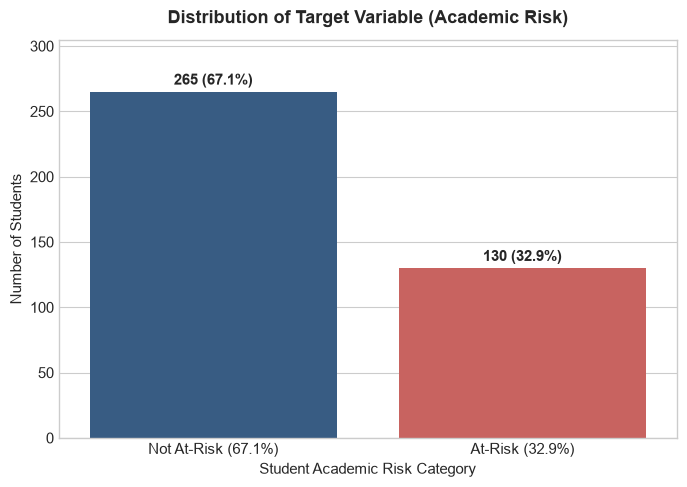

In [5]:
plt.figure(figsize=(7, 5))
palette = ['#2b5c8f', '#d9534f']
ax = sns.countplot(x='At_Risk', data=df, hue='At_Risk', palette=palette, legend=False)
plt.title("Distribution of Target Variable (Academic Risk)", fontsize=13, fontweight='bold', pad=12)
plt.xticks([0, 1], ['Not At-Risk (67.1%)', 'At-Risk (32.9%)'])
plt.xlabel("Student Academic Risk Category")
plt.ylabel("Number of Students")

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h)} ({h/len(df)*100:.1f}%)", (p.get_x() + p.get_width() / 2., h + 3),
                ha='center', va='bottom', fontsize=11, fontweight='semibold')

plt.ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

## 4. Key Academic Predictors & Early Indicators
In early-warning systems, previous semester failures and term grades ($G1, G2$) strongly indicate downstream failure risk.

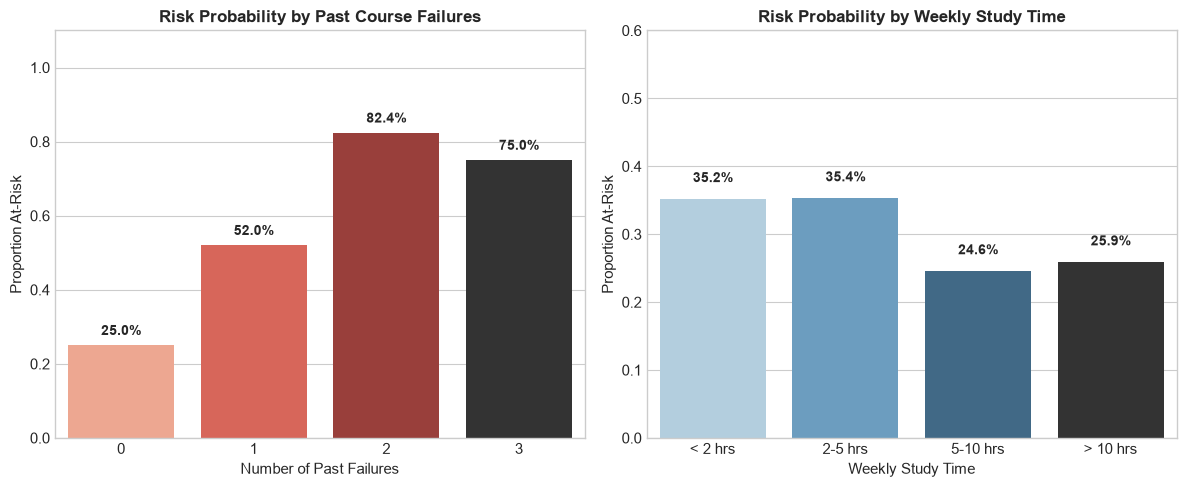

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ax1 = sns.barplot(x='failures', y='At_Risk', data=df, hue='failures', palette='Reds_d', legend=False, errorbar=None)
plt.title("Risk Probability by Past Course Failures", fontsize=12, fontweight='bold')
plt.xlabel("Number of Past Failures")
plt.ylabel("Proportion At-Risk")
for p in ax1.patches:
    h = p.get_height()
    ax1.annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h + 0.02),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0, 1.1)

plt.subplot(1, 2, 2)
ax2 = sns.barplot(x='studytime', y='At_Risk', data=df, hue='studytime', palette='Blues_d', legend=False, errorbar=None)
plt.title("Risk Probability by Weekly Study Time", fontsize=12, fontweight='bold')
plt.xticks([0, 1, 2, 3], ['< 2 hrs', '2-5 hrs', '5-10 hrs', '> 10 hrs'])
plt.xlabel("Weekly Study Time")
plt.ylabel("Proportion At-Risk")
for p in ax2.patches:
    h = p.get_height()
    ax2.annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h + 0.02),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0, 0.6)

plt.tight_layout()
plt.show()

## 5. Behavioral & Environmental Influences (Alcohol, Absences, Support)

C:\Users\ronni\AppData\Local\Temp\ipykernel_15488\1460815149.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Not At-Risk', 'At-Risk'])


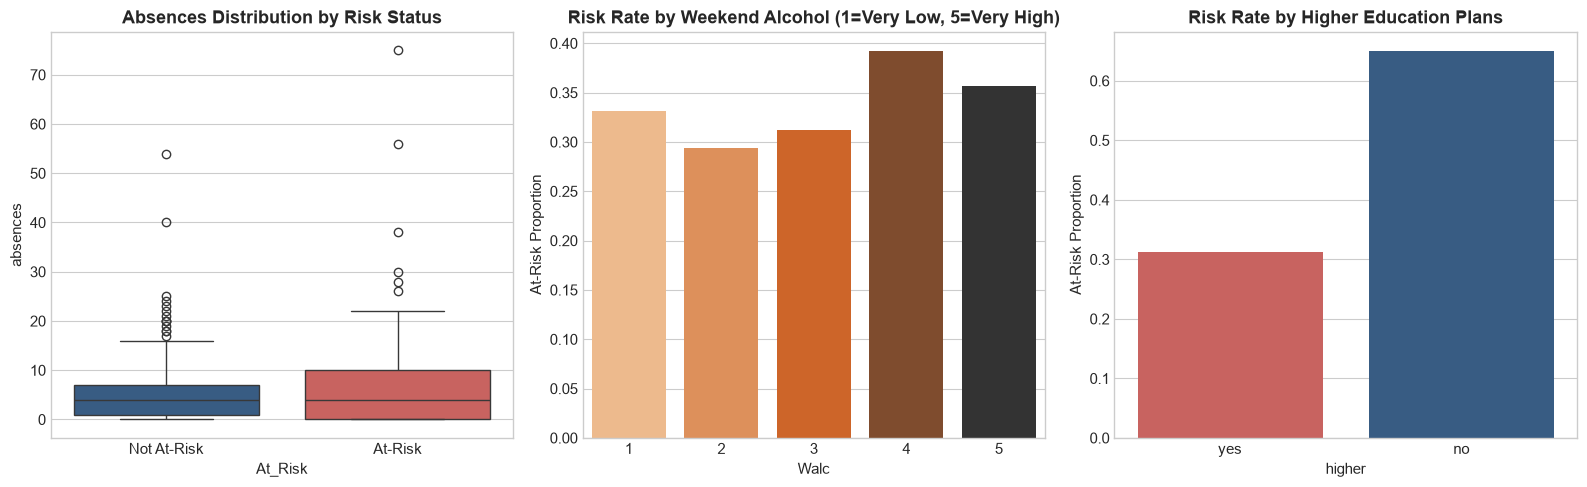

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Absences vs Risk
sns.boxplot(x='At_Risk', y='absences', data=df, ax=axes[0], palette=['#2b5c8f', '#d9534f'], hue='At_Risk', legend=False)
axes[0].set_title("Absences Distribution by Risk Status", fontweight='bold')
axes[0].set_xticklabels(['Not At-Risk', 'At-Risk'])

# Weekend Alcohol Consumption
sns.barplot(x='Walc', y='At_Risk', data=df, ax=axes[1], palette='Oranges_d', hue='Walc', legend=False, errorbar=None)
axes[1].set_title("Risk Rate by Weekend Alcohol (1=Very Low, 5=Very High)", fontweight='bold')
axes[1].set_ylabel("At-Risk Proportion")

# Higher Education Aspiration
sns.barplot(x='higher', y='At_Risk', data=df, ax=axes[2], palette=['#d9534f', '#2b5c8f'], hue='higher', legend=False, errorbar=None)
axes[2].set_title("Risk Rate by Higher Education Plans", fontweight='bold')
axes[2].set_ylabel("At-Risk Proportion")

plt.tight_layout()
plt.show()

## 6. Correlation Analysis with Academic Risk

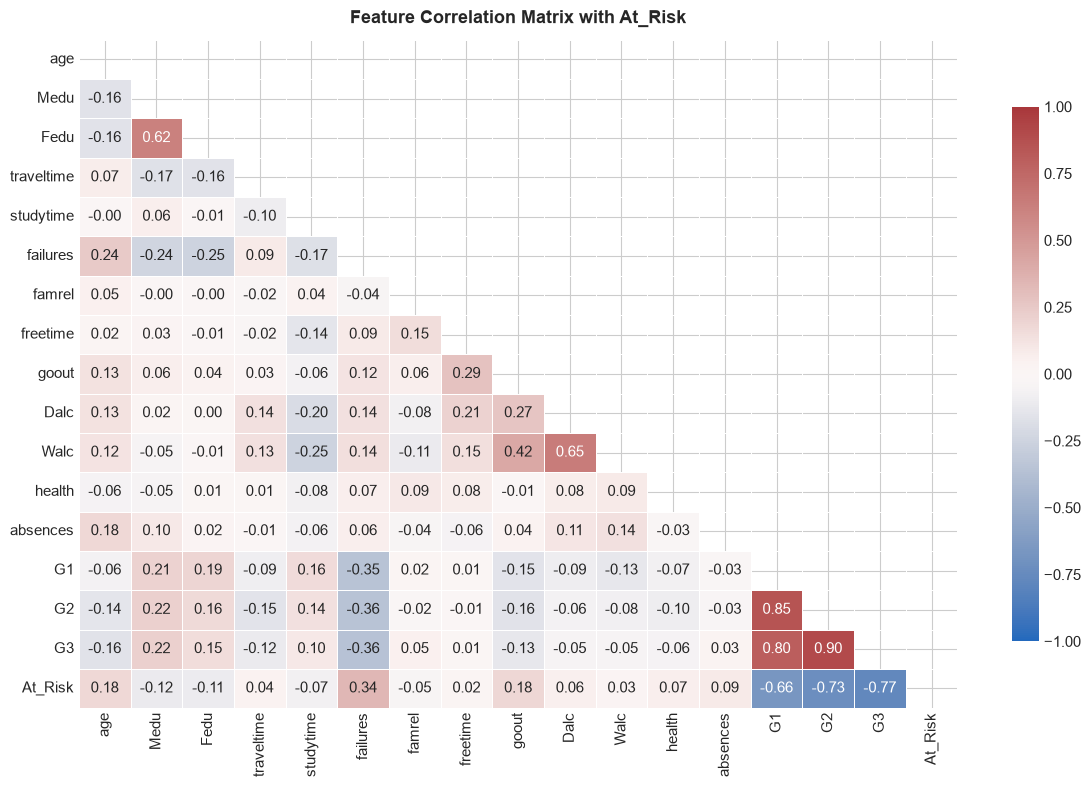

Top Predictors Correlated with At_Risk:
failures      0.337731
goout         0.183399
age           0.179645
absences      0.092244
health        0.065668
Dalc          0.057343
traveltime    0.044446
Walc          0.029957
freetime      0.018321
famrel       -0.046683
studytime    -0.074613
Fedu         -0.108057
Medu         -0.115396
G1           -0.664979
G2           -0.725407
Name: At_Risk, dtype: float64


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='vlag', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Feature Correlation Matrix with At_Risk", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("Top Predictors Correlated with At_Risk:")
print(corr['At_Risk'].drop(['At_Risk', 'G3']).sort_values(ascending=False))

## 7. Key Findings & Research Insights for CA-III Paper
1. **Target Imbalance**: 32.9% of students (130/395) are classified as `At-Risk`. This moderate class imbalance warrants stratified evaluation and focus on Recall and Precision-Recall AUC (PR-AUC).
2. **Dominant Early Warning Feature**: Past academic failures (`failures`) exhibit the strongest positive correlation with academic risk ($r pprox 0.36$). Students with $\ge 2$ failures have $>75\%$ risk of failing again.
3. **Behavioral Mitigators**: Increased study time ($>5$ hours/week) and aspirations for higher education (`higher = yes`) are associated with a substantial reduction in risk ($<15\%$ risk).
4. **Leakage Precaution for Modeling**: First and second-period grades ($G1, G2$) are highly correlated with $G3$. In our modeling pipeline, we should benchmark models **with** and **without** intermediate term grades to evaluate true early-stage prediction prior to first exam results.